# ERCP Preprocessing Benchmark Notebook


In [1]:
import os
import json
import copy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
    average_precision_score,
)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

DATA_ROOT = '/mounts/mecd-ap-g5/data'
RESULTS_ROOT = '/mounts/mecd-ap-g5/results'
MODELS_ROOT = '/mounts/mecd-ap-g5/models'
NOTEBOOK_NAME = 'preprocessing_benchmark'
RESULTS_DIR = os.path.join(RESULTS_ROOT, NOTEBOOK_NAME)
MODELS_DIR = os.path.join(MODELS_ROOT, NOTEBOOK_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

SEED = 42
IMG_SIZE = 320
BATCH_SIZE = 32
NUM_WORKERS = 8
TOP_MODEL_NAME = 'resnet50'
NUM_EPOCHS = 12
PATIENCE = 4

print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    print('WARNING: Using CPU')

print(f'RESULTS_DIR: {RESULTS_DIR}')
print(f'MODELS_DIR: {MODELS_DIR}')

CUDA available: True
GPU: NVIDIA RTX 6000 Ada Generation
VRAM: 50.9 GB
RESULTS_DIR: /mounts/mecd-ap-g5/results/preprocessing_benchmark
MODELS_DIR: /mounts/mecd-ap-g5/models/preprocessing_benchmark


Total samples: 19317

Label counts:
Label
Unlabelled             13798
Lithiasis               2651
Malignant Stricture     1281
Normal                  1012
Biliary Leaks            361
Benign Stricture         214
Name: count, dtype: int64

Keep counts:
Keep
Keep       15216
Discard     4101
Name: count, dtype: int64

Image type counts:
image_type
S    18825
V      492
Name: count, dtype: int64

Label x image_type cross-tab:
image_type               S    V
Label                          
Benign Stricture       214    0
Biliary Leaks          344   17
Lithiasis             2601   50
Malignant Stricture   1249   32
Normal                 951   61
Unlabelled           13466  332

Filtered label/type combinations:
                 Label image_type  count
0     Benign Stricture          S     63
1        Biliary Leaks          S    146
2        Biliary Leaks          V      5
3            Lithiasis          S    712
4            Lithiasis          V     14
5  Malignant Stricture          

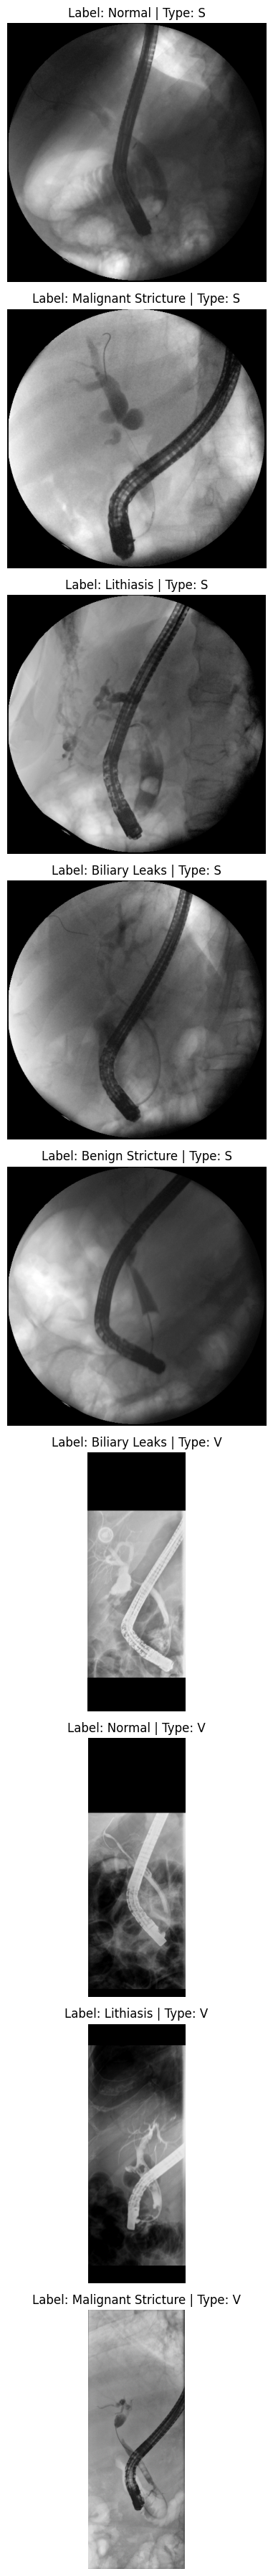

In [2]:
METADATA_PATH = os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', 'metadata.csv')
df = pd.read_csv(METADATA_PATH)
print('Total samples:', len(df))
print('\nLabel counts:')
print(df['Label'].value_counts())
print('\nKeep counts:')
print(df['Keep'].value_counts())
print('\nImage type counts:')
print(df['image_type'].value_counts())
print('\nLabel x image_type cross-tab:')
combo_counts = pd.crosstab(df['Label'], df['image_type'])
print(combo_counts)

filtered_pairs = df[(df['Keep'].astype(str).str.strip().str.lower() == 'keep') & (~df['Label'].astype(str).str.strip().str.lower().isin({'unlabeled', 'unlabelled', 'unlabbeled'}))].copy()
combo_summary = filtered_pairs.groupby(['Label', 'image_type']).size().reset_index(name='count')
print('\nFiltered label/type combinations:')
print(combo_summary)

sample_combos = filtered_pairs.groupby(['Label', 'image_type']).head(1).copy()
fig, axes = plt.subplots(len(sample_combos), 1, figsize=(8, 4 * len(sample_combos)))
if len(sample_combos) == 1:
    axes = [axes]
for axis, (_, row) in zip(axes, sample_combos.iterrows()):
    image = Image.open(os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', row['processed_image_path'])).convert('RGB')
    axis.imshow(image)
    axis.set_title(f"Label: {row['Label']} | Type: {row['image_type']}")
    axis.axis('off')
plt.tight_layout()
plt.show()

                               content_bbox_area_ratio            \
                                                  mean       std   
Label               image_type                                     
Benign Stricture    S                         0.981301  0.002829   
Biliary Leaks       S                         0.978523  0.014078   
                    V                         0.803523  0.099138   
Lithiasis           S                         0.980572  0.008398   
                    V                         0.821113  0.111653   
Malignant Stricture S                         0.981927  0.002971   
                    V                         0.943523  0.104489   
Normal              S                         0.981183  0.003747   
                    V                         0.728458  0.079654   

                               non_black_pixel_ratio           edge_darkness  \
                                                mean       std          mean   
Label               ima

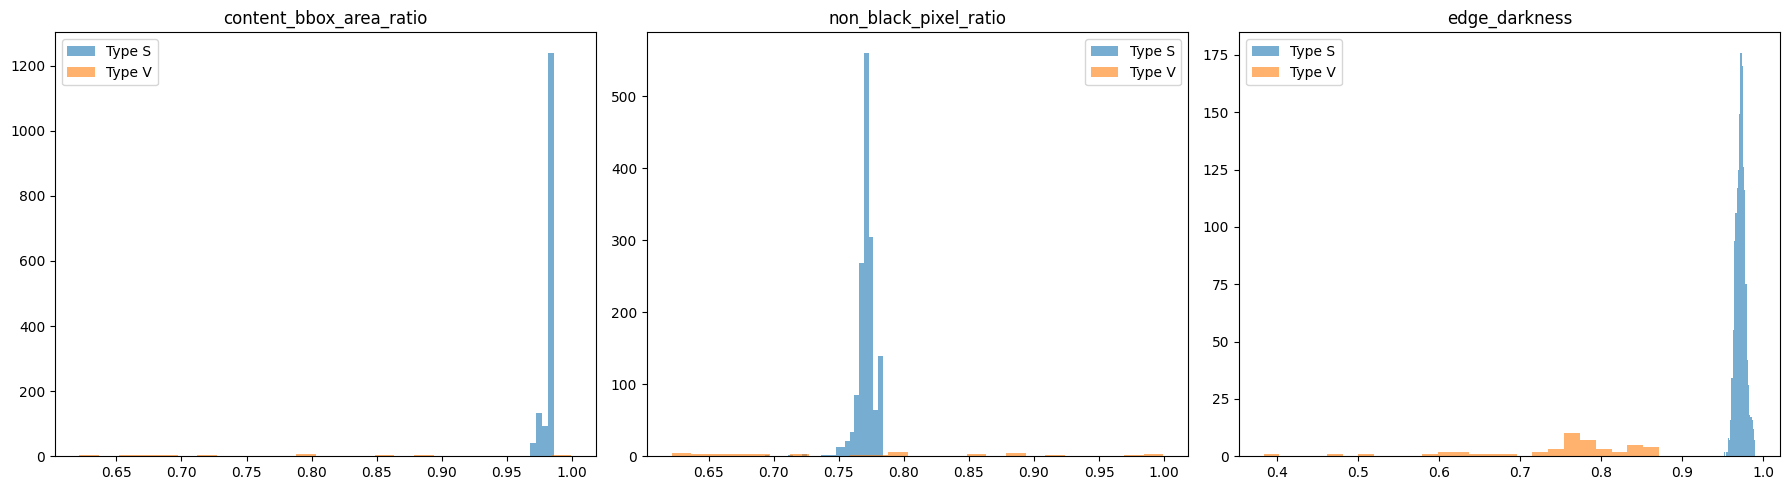

Saved content/border metrics to /mounts/mecd-ap-g5/results/preprocessing_benchmark/content_border_metrics.csv


In [3]:
def estimate_content_metrics(image_path, threshold=10):
    image = Image.open(image_path).convert('RGB')
    image_array = np.array(image)
    grayscale = image_array.mean(axis=2)
    content_mask = grayscale > threshold

    if not content_mask.any():
        return {
            'content_bbox_area_ratio': 0.0,
            'non_black_pixel_ratio': 0.0,
            'edge_darkness': 1.0,
        }

    ys, xs = np.where(content_mask)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    bbox_area = (y_max - y_min + 1) * (x_max - x_min + 1)
    image_area = image_array.shape[0] * image_array.shape[1]

    top_edge = grayscale[:5, :].mean() / 255.0
    bottom_edge = grayscale[-5:, :].mean() / 255.0
    left_edge = grayscale[:, :5].mean() / 255.0
    right_edge = grayscale[:, -5:].mean() / 255.0
    edge_darkness = 1.0 - np.mean([top_edge, bottom_edge, left_edge, right_edge])

    return {
        'content_bbox_area_ratio': bbox_area / image_area,
        'non_black_pixel_ratio': content_mask.mean(),
        'edge_darkness': edge_darkness,
    }

analysis_df = filtered_pairs.copy()
analysis_df['image_path'] = analysis_df['processed_image_path'].apply(lambda path: os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', path))
metrics_rows = []
for _, row in analysis_df.iterrows():
    metrics = estimate_content_metrics(row['image_path'])
    metrics_rows.append({
        'Label': row['Label'],
        'image_type': row['image_type'],
        **metrics,
    })
metrics_df = pd.DataFrame(metrics_rows)
summary_metrics = metrics_df.groupby(['Label', 'image_type']).agg(['mean', 'std'])
print(summary_metrics)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, column in zip(axes, ['content_bbox_area_ratio', 'non_black_pixel_ratio', 'edge_darkness']):
    for image_type in ['S', 'V']:
        subset = metrics_df[metrics_df['image_type'] == image_type]
        axis.hist(subset[column], bins=25, alpha=0.6, label=f'Type {image_type}')
    axis.set_title(column)
    axis.legend()
plt.tight_layout()
plt.show()

metrics_csv_path = os.path.join(RESULTS_DIR, 'content_border_metrics.csv')
metrics_df.to_csv(metrics_csv_path, index=False)
print(f'Saved content/border metrics to {metrics_csv_path}')

Available preprocessing pipelines:
  - baseline_resize
  - crop_resize
  - crop_pad_resize


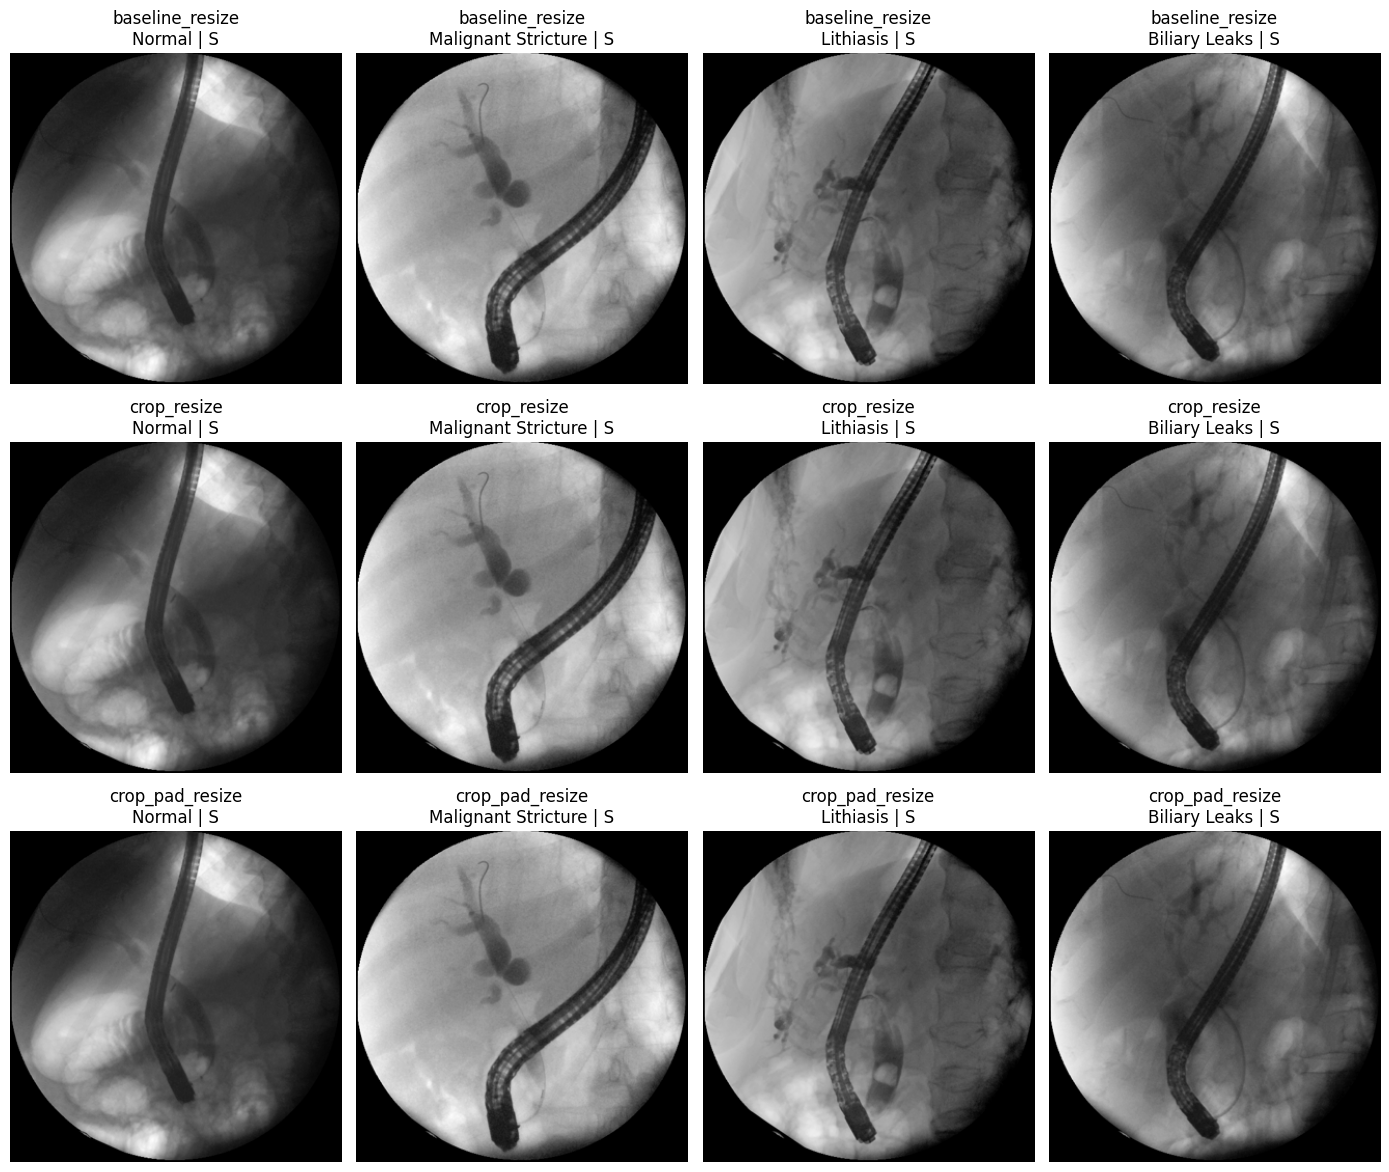

In [4]:
def crop_content_bbox(image, threshold=10, padding=8):
    image_array = np.array(image)
    grayscale = image_array.mean(axis=2)
    content_mask = grayscale > threshold
    if not content_mask.any():
        return image
    ys, xs = np.where(content_mask)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    y_min = max(0, y_min - padding)
    x_min = max(0, x_min - padding)
    y_max = min(image_array.shape[0] - 1, y_max + padding)
    x_max = min(image_array.shape[1] - 1, x_max + padding)
    return image.crop((x_min, y_min, x_max + 1, y_max + 1))


def pad_to_square(image, fill=0):
    width, height = image.size
    side = max(width, height)
    left = (side - width) // 2
    top = (side - height) // 2
    right = side - width - left
    bottom = side - height - top
    return ImageOps.expand(image, border=(left, top, right, bottom), fill=fill)


def pipeline_baseline(image):
    return image


def pipeline_crop_resize(image):
    return crop_content_bbox(image, threshold=10, padding=10)


def pipeline_crop_pad_resize(image):
    cropped = crop_content_bbox(image, threshold=10, padding=10)
    return pad_to_square(cropped, fill=0)

PIPELINES = {
    'baseline_resize': pipeline_baseline,
    'crop_resize': pipeline_crop_resize,
    'crop_pad_resize': pipeline_crop_pad_resize,
}

print('Available preprocessing pipelines:')
for pipeline_name in PIPELINES:
    print(f'  - {pipeline_name}')

fig, axes = plt.subplots(len(PIPELINES), 4, figsize=(14, 4 * len(PIPELINES)))
example_rows = filtered_pairs.groupby('Label').head(1).head(4)
for row_index, (_, row) in enumerate(example_rows.iterrows()):
    image = Image.open(os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', row['processed_image_path'])).convert('RGB')
    for col_index, (pipeline_name, pipeline_fn) in enumerate(PIPELINES.items()):
        processed = pipeline_fn(image)
        processed = processed.resize((IMG_SIZE, IMG_SIZE))
        axes[col_index, row_index].imshow(processed)
        axes[col_index, row_index].set_title(f'{pipeline_name}\n{row["Label"]} | {row["image_type"]}')
        axes[col_index, row_index].axis('off')
plt.tight_layout()
plt.show()

In [5]:
EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled'}
filtered = df[(df['Keep'].astype(str).str.strip().str.lower() == 'keep') & (~df['Label'].astype(str).str.strip().str.lower().isin(EXCLUDED_LABELS))].copy()
filtered['image_path'] = filtered['processed_image_path'].apply(lambda path: os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', path))
filtered = filtered[filtered['image_path'].apply(os.path.exists)].copy()
filtered['target'] = filtered['Label'].astype('category').cat.codes
class_names = list(filtered['Label'].astype('category').cat.categories)
class_to_idx = {label_name: index for index, label_name in enumerate(class_names)}
idx_to_class = {index: label_name for label_name, index in class_to_idx.items()}
filtered['target'] = filtered['Label'].map(class_to_idx)

patient_summary = filtered.groupby('patient_id').agg(patient_label=('Label', lambda values: values.mode().iloc[0])).reset_index()
train_patients, temp_patients = train_test_split(patient_summary, test_size=0.30, random_state=SEED, stratify=patient_summary['patient_label'])
val_patients, test_patients = train_test_split(temp_patients, test_size=0.50, random_state=SEED, stratify=temp_patients['patient_label'])

train_df = filtered[filtered['patient_id'].isin(train_patients['patient_id'])].copy()
val_df = filtered[filtered['patient_id'].isin(val_patients['patient_id'])].copy()
test_df = filtered[filtered['patient_id'].isin(test_patients['patient_id'])].copy()

class PipelineDataset(Dataset):
    def __init__(self, dataframe, pipeline_fn, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.pipeline_fn = pipeline_fn
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        image = self.pipeline_fn(image)
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row['target'])

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.05, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class_counts = train_df['target'].value_counts().sort_index()
class_weights = torch.tensor(len(train_df) / (len(class_counts) * class_counts.values), dtype=torch.float32, device=device)
weight_lookup = {class_index: float(weight) for class_index, weight in enumerate(class_weights.detach().cpu().numpy())}
sample_weights = train_df['target'].map(weight_lookup).astype(float).tolist()
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

PIPELINE_DATASETS = {}
for pipeline_name, pipeline_fn in PIPELINES.items():
    PIPELINE_DATASETS[pipeline_name] = {
        'train': PipelineDataset(train_df, pipeline_fn, transform=base_transform),
        'val': PipelineDataset(val_df, pipeline_fn, transform=base_transform),
        'test': PipelineDataset(test_df, pipeline_fn, transform=base_transform),
    }

print('Class weights:')
for class_index, class_name in enumerate(class_names):
    print(f'{class_name}: {class_weights[class_index].item():.3f}')
print(f'\nTrain/val/test sizes: {len(train_df)}, {len(val_df)}, {len(test_df)}')

Class weights:
Benign Stricture: 5.380
Biliary Leaks: 2.795
Lithiasis: 0.426
Malignant Stricture: 0.936
Normal: 0.961

Train/val/test sizes: 1076, 240, 252


In [6]:
def build_top_model(model_name, num_classes):
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'convnext_tiny':
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    elif model_name == 'efficientnet_v2_s':
        model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    else:
        raise ValueError(f'Unsupported model: {model_name}')
    return model


def print_model_details(model_name, model):
    total_parameters = sum(parameter.numel() for parameter in model.parameters())
    trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    print(f'\n=== {model_name} architecture ===')
    print(model)
    print(f'Total parameters: {total_parameters:,}')
    print(f'Trainable parameters: {trainable_parameters:,}')

model_preview = build_top_model(TOP_MODEL_NAME, len(class_names))
print_model_details(TOP_MODEL_NAME, model_preview)
print(f'Using top model: {TOP_MODEL_NAME}')


=== resnet50 architecture ===
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, 

In [7]:
def train_model_for_pipeline(pipeline_name, train_dataset, val_dataset, class_names, device, results_dir, models_dir):
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

    model = build_top_model(TOP_MODEL_NAME, len(class_names)).to(device)
    print_model_details(TOP_MODEL_NAME, model)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_state = copy.deepcopy(model.state_dict())
    best_val_macro_f1 = float('-inf')
    best_epoch = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_macro_f1': []}

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_targets = []
        train_predictions = []
        running_loss = 0.0

        for images, targets in tqdm(train_loader, desc=f'{pipeline_name} | Epoch {epoch + 1}/{NUM_EPOCHS}', leave=False):
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            predictions = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
            running_loss += loss.item() * images.size(0)
            train_targets.extend(targets.detach().cpu().numpy())
            train_predictions.extend(predictions.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_targets, train_predictions)
        val_metrics, _, _, _ = evaluate_model(model, val_loader, criterion, class_names, device)
        val_loss = val_metrics['loss']
        val_acc = val_metrics['accuracy']
        val_macro_f1 = val_metrics['macro_f1']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_macro_f1'].append(val_macro_f1)
        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            patience_counter = 0
            torch.save(best_state, os.path.join(models_dir, f'{pipeline_name}_{TOP_MODEL_NAME}.pth'))
        else:
            patience_counter += 1

        print(f'{pipeline_name} | Epoch {epoch + 1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro F1: {val_macro_f1:.4f}')
        if patience_counter >= PATIENCE:
            print(f'Early stopping for {pipeline_name}')
            break

    model.load_state_dict(best_state)
    return model, history, best_epoch, best_val_macro_f1

In [8]:
def compute_multiclass_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        metrics['roc_auc_ovo_macro'] = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovo')
    except ValueError:
        metrics['roc_auc_ovo_macro'] = np.nan
    try:
        metrics['pr_auc_macro'] = average_precision_score(y_true_bin, y_prob, average='macro')
    except ValueError:
        metrics['pr_auc_macro'] = np.nan
    return metrics


def evaluate_model(model, loader, criterion, class_names, device):
    model.eval()
    all_targets = []
    all_predictions = []
    all_probabilities = []
    running_loss = 0.0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    average_loss = running_loss / len(loader.dataset)
    all_probabilities = np.array(all_probabilities)
    metrics = compute_multiclass_metrics(all_targets, all_predictions, all_probabilities, class_names)
    metrics['loss'] = average_loss
    return metrics, np.array(all_targets), np.array(all_predictions), all_probabilities


def plot_curves(history, pipeline_name, results_dir):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{pipeline_name} - Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, history['train_acc'], label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], label='Val Acc')
    axes[1].set_title(f'{pipeline_name} - Accuracy Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, f'{pipeline_name}_training_curves.png'), dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def plot_roc_curve(y_true, y_prob, class_names, pipeline_name, results_dir):
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    fig, axis = plt.subplots(figsize=(8, 6))
    for class_index, class_name in enumerate(class_names):
        if y_true_bin[:, class_index].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, class_index], y_prob[:, class_index])
        axis.plot(fpr, tpr, label=f'{class_name} (AUC = {auc(fpr, tpr):.3f})')
    axis.plot([0, 1], [0, 1], 'k--', label='Chance')
    axis.set_title(f'{pipeline_name} - ROC Curves')
    axis.set_xlabel('False Positive Rate')
    axis.set_ylabel('True Positive Rate')
    axis.legend(loc='lower right')
    axis.grid(alpha=0.3)
    plt.savefig(os.path.join(results_dir, f'{pipeline_name}_roc_curve.png'), dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print('Evaluation helpers ready.')

Evaluation helpers ready.



Running pipeline: baseline_resize

=== resnet50 architecture ===
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequen

baseline_resize | Epoch 01 | Train Loss: 0.8962 | Val Loss: 1.5801 | Val Macro F1: 0.1337


baseline_resize | Epoch 02 | Train Loss: 0.3171 | Val Loss: 1.4367 | Val Macro F1: 0.2332


baseline_resize | Epoch 03 | Train Loss: 0.1144 | Val Loss: 1.9177 | Val Macro F1: 0.3138


baseline_resize | Epoch 04 | Train Loss: 0.0555 | Val Loss: 1.6878 | Val Macro F1: 0.4392


baseline_resize | Epoch 05 | Train Loss: 0.0420 | Val Loss: 2.5751 | Val Macro F1: 0.2747


baseline_resize | Epoch 06 | Train Loss: 0.0358 | Val Loss: 1.8186 | Val Macro F1: 0.3835


baseline_resize | Epoch 07 | Train Loss: 0.0245 | Val Loss: 1.9588 | Val Macro F1: 0.3501


baseline_resize | Epoch 08 | Train Loss: 0.0129 | Val Loss: 2.2554 | Val Macro F1: 0.3146
Early stopping for baseline_resize


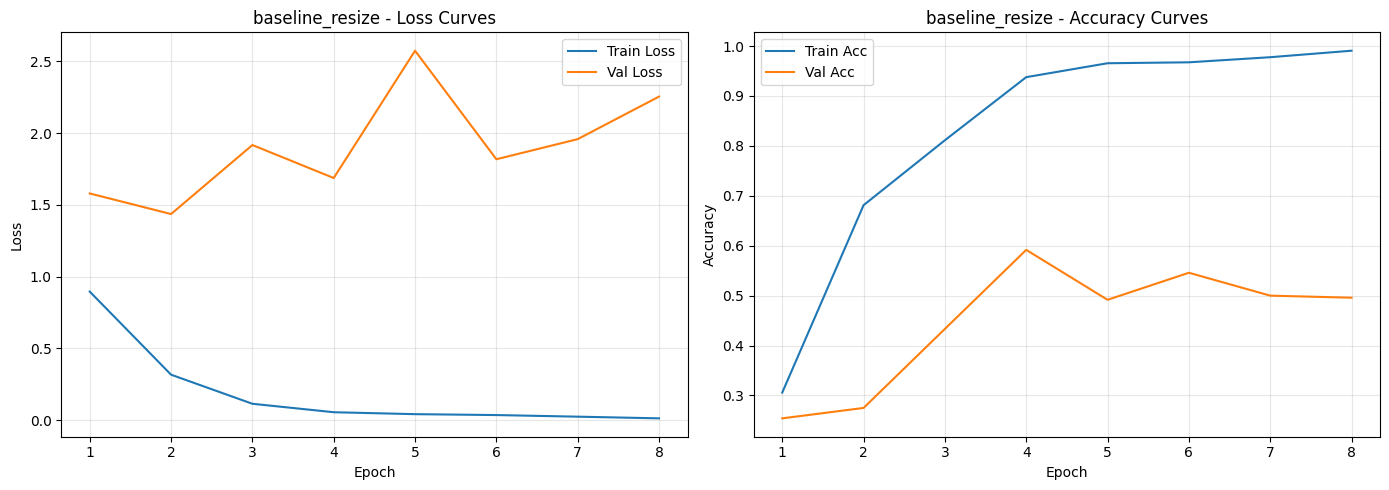

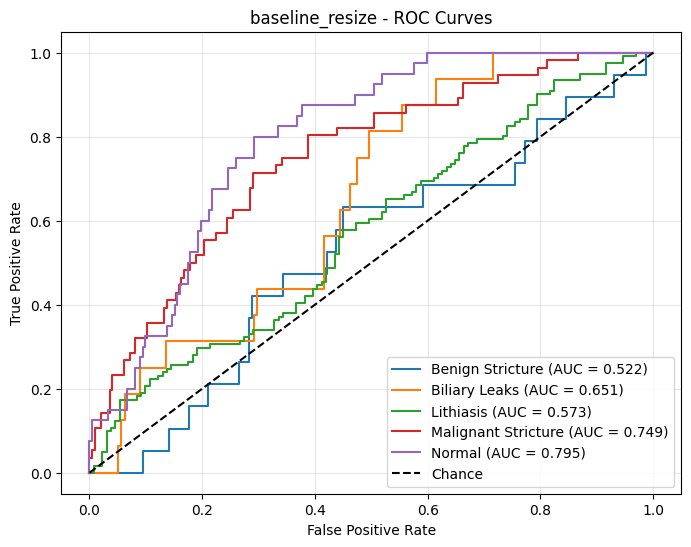


Running pipeline: crop_resize

=== resnet50 architecture ===
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential

crop_resize | Epoch 01 | Train Loss: 0.8081 | Val Loss: 1.5487 | Val Macro F1: 0.1806


crop_resize | Epoch 02 | Train Loss: 0.2754 | Val Loss: 1.7366 | Val Macro F1: 0.1598


crop_resize | Epoch 03 | Train Loss: 0.1314 | Val Loss: 1.6714 | Val Macro F1: 0.2585


crop_resize | Epoch 04 | Train Loss: 0.0870 | Val Loss: 1.9532 | Val Macro F1: 0.3165


crop_resize | Epoch 05 | Train Loss: 0.0399 | Val Loss: 1.7726 | Val Macro F1: 0.3529


crop_resize | Epoch 06 | Train Loss: 0.0437 | Val Loss: 2.2440 | Val Macro F1: 0.2745


crop_resize | Epoch 07 | Train Loss: 0.0222 | Val Loss: 2.1577 | Val Macro F1: 0.3088


crop_resize | Epoch 08 | Train Loss: 0.0195 | Val Loss: 2.4689 | Val Macro F1: 0.3107


crop_resize | Epoch 09 | Train Loss: 0.0092 | Val Loss: 2.1269 | Val Macro F1: 0.3493
Early stopping for crop_resize


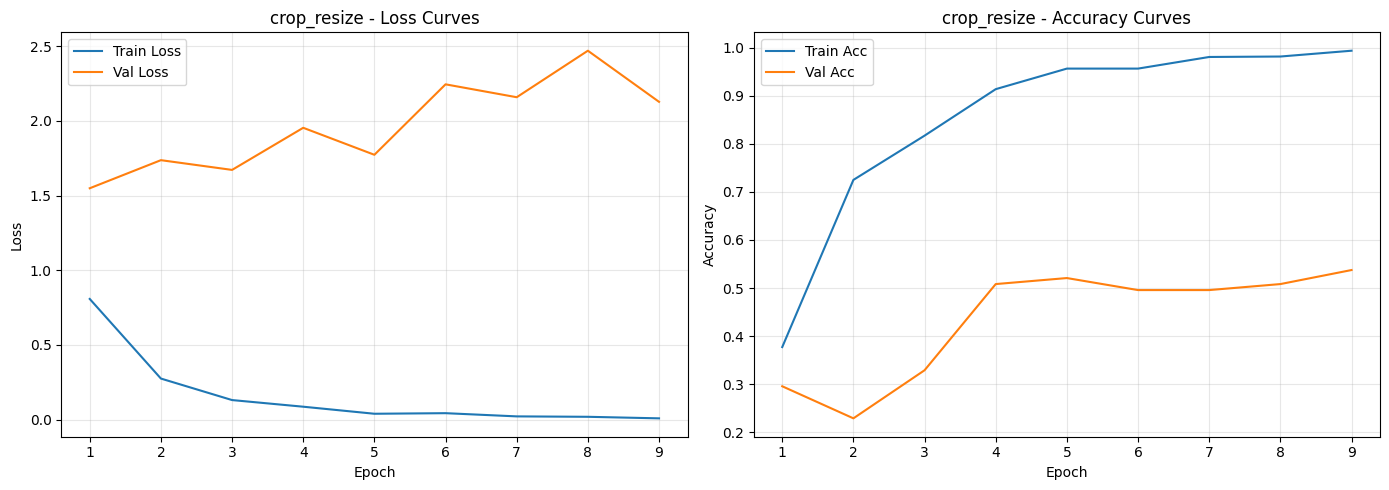

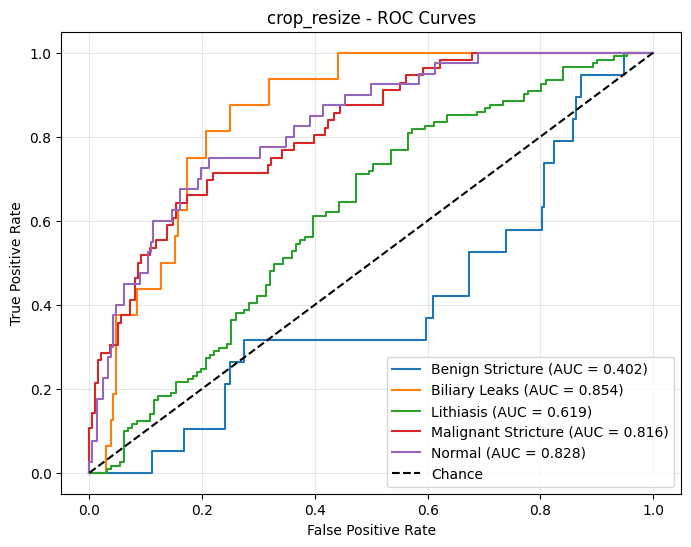


Running pipeline: crop_pad_resize

=== resnet50 architecture ===
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequen

crop_pad_resize | Epoch 01 | Train Loss: 0.8049 | Val Loss: 1.6704 | Val Macro F1: 0.0929


crop_pad_resize | Epoch 02 | Train Loss: 0.2531 | Val Loss: 1.4119 | Val Macro F1: 0.2471


crop_pad_resize | Epoch 03 | Train Loss: 0.1224 | Val Loss: 1.8447 | Val Macro F1: 0.3392


crop_pad_resize | Epoch 04 | Train Loss: 0.0633 | Val Loss: 1.9326 | Val Macro F1: 0.3670


crop_pad_resize | Epoch 05 | Train Loss: 0.0366 | Val Loss: 1.4694 | Val Macro F1: 0.4094


crop_pad_resize | Epoch 06 | Train Loss: 0.0293 | Val Loss: 2.0867 | Val Macro F1: 0.3765


crop_pad_resize | Epoch 07 | Train Loss: 0.0249 | Val Loss: 1.8246 | Val Macro F1: 0.4068


crop_pad_resize | Epoch 08 | Train Loss: 0.0253 | Val Loss: 2.7380 | Val Macro F1: 0.3017


crop_pad_resize | Epoch 09 | Train Loss: 0.0149 | Val Loss: 1.7568 | Val Macro F1: 0.4041
Early stopping for crop_pad_resize


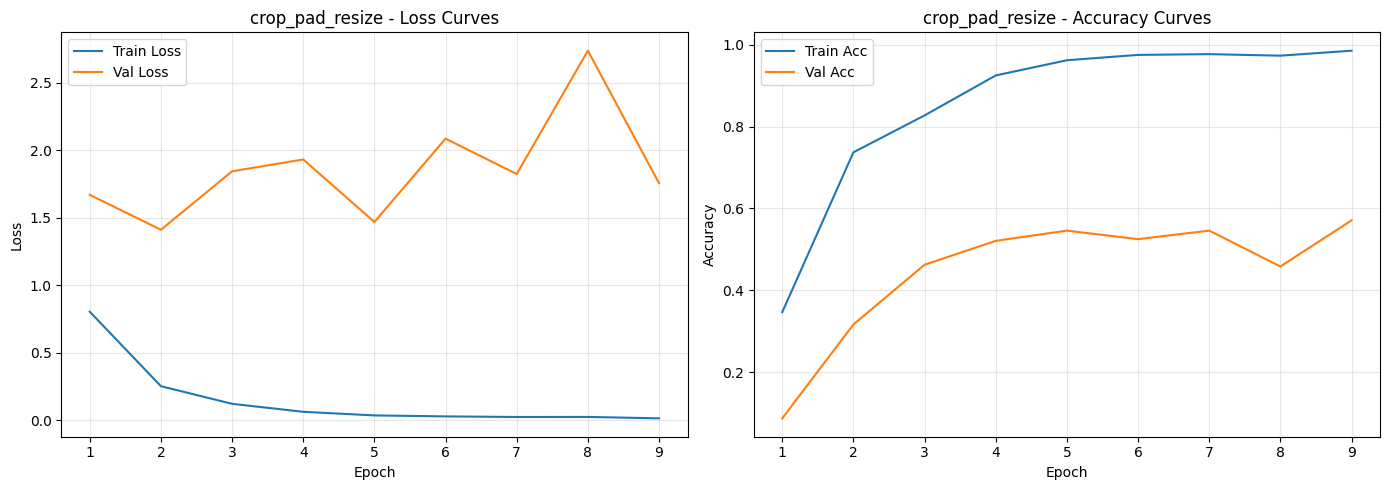

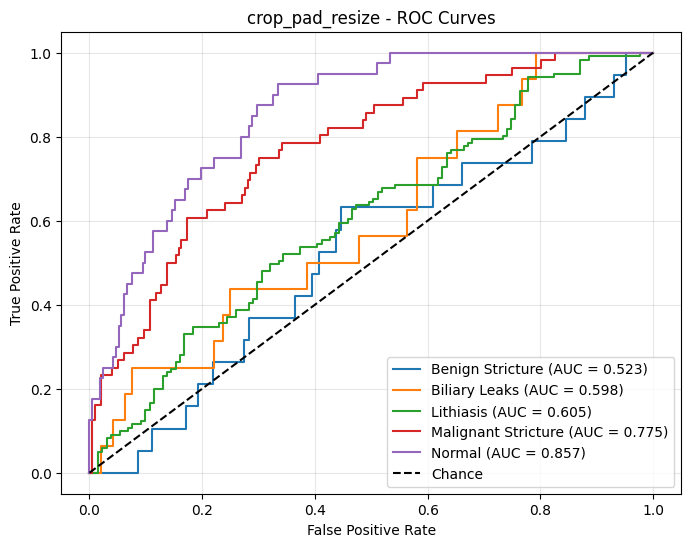


Pipeline benchmark summary:
     pipeline_name  best_epoch  best_val_macro_f1  test_accuracy  \
1      crop_resize           5           0.352918       0.531746   
2  crop_pad_resize           5           0.409441       0.456349   
0  baseline_resize           4           0.439162       0.468254   

   test_balanced_accuracy  test_macro_f1  test_macro_precision  \
1                0.373253       0.341422              0.316732   
2                0.356216       0.298850              0.274284   
0                0.281251       0.268813              0.263747   

   test_macro_recall  test_roc_auc_ovo_macro  test_pr_auc_macro  test_loss  
1           0.373253                0.703971           0.386177   2.193640  
2           0.356216                0.671730           0.362600   2.583258  
0           0.281251                0.658081           0.324738   2.179233  

Best preprocessing pipeline: crop_resize

This is the point where you can keep the best pipeline and later re-run the model 

In [9]:
PIPELINE_RESULTS = []
for pipeline_name, datasets in PIPELINE_DATASETS.items():
    print(f'\nRunning pipeline: {pipeline_name}')
    model, history, best_epoch, best_val_macro_f1 = train_model_for_pipeline(
        pipeline_name,
        datasets['train'],
        datasets['val'],
        class_names,
        device,
        RESULTS_DIR,
        MODELS_DIR,
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    test_metrics, y_true, y_pred, y_prob = evaluate_model(model, DataLoader(datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()), criterion, class_names, device)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    confusion = confusion_matrix(y_true, y_pred)
    plot_curves(history, pipeline_name, RESULTS_DIR)
    plot_roc_curve(y_true, y_prob, class_names, pipeline_name, RESULTS_DIR)

    with open(os.path.join(RESULTS_DIR, f'{pipeline_name}_classification_report.json'), 'w') as handle:
        json.dump(report, handle, indent=2)
    with open(os.path.join(RESULTS_DIR, f'{pipeline_name}_history.json'), 'w') as handle:
        json.dump(history, handle, indent=2)
    pd.DataFrame(confusion, index=class_names, columns=class_names).to_csv(os.path.join(RESULTS_DIR, f'{pipeline_name}_confusion_matrix.csv'))

    PIPELINE_RESULTS.append({
        'pipeline_name': pipeline_name,
        'best_epoch': best_epoch,
        'best_val_macro_f1': best_val_macro_f1,
        **{f'test_{key}': value for key, value in test_metrics.items()},
    })

pipeline_results_df = pd.DataFrame(PIPELINE_RESULTS).sort_values(by='test_macro_f1', ascending=False)
pipeline_results_df.to_csv(os.path.join(RESULTS_DIR, 'pipeline_benchmark_summary.csv'), index=False)
print('\nPipeline benchmark summary:')
print(pipeline_results_df)

best_pipeline_name = pipeline_results_df.iloc[0]['pipeline_name']
print(f'\nBest preprocessing pipeline: {best_pipeline_name}')

print('\nThis is the point where you can keep the best pipeline and later re-run the model tuning with stronger augmentation and loss variants.')